# Example: Let's Build and Test a Trade Bot
In this example, we combine several concepts from the course to build a trade bot that makes buy, sell, or hold decisions based on moving averages and utility maximization.

> __Learning Objectives:__
>
> By the end of this example, you will be able to:
> * __Generate synthetic price data using hidden Markov models:__ Simulate market price trajectories using a hidden Markov model estimated from historical data, and compute corresponding asset prices using single index model parameters.
> * __Implement moving average crossover signals:__ Compute short-term and long-term exponential moving averages, generate a risk-aversion parameter time series based on their crossover, and use these signals to inform portfolio reallocation decisions.
> * __Evaluate trade bot performance against benchmarks:__ Compare the wealth trajectory of a dynamically reallocating portfolio against passive alternatives such as the SPY ETF and risk-free STRIPS bonds.


Let's get started!
___

## Setup, Data, and Prerequisites
First, we set up the computational environment by including the `Include.jl` file and loading any needed resources.

> __Include:__ The [`include(...)` command](https://docs.julialang.org/en/v1/base/base/#include) evaluates the contents of the input source file, `Include.jl`, in the notebook's global scope. The `Include.jl` file sets paths, loads required external packages, etc. For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/). 

Let's set up our code environment:

In [1]:
include(joinpath(@__DIR__, "Include-tradebot-synthetic.jl")); # include the Include.jl file

For additional information on functions and types used in this material, see the [Julia programming language documentation](https://docs.julialang.org/en/v1/) and the [VLQuantitativeFinancePackage.jl documentation](https://github.com/varnerlab/VLQuantitativeFinancePackage.jl). 

### Data, Models and Constants
Before we implement the trade bot, we need to load up some models and data first. First, let's load the HMM model that we estimated using historical data (2014 - 2024). To start, we specify the `path_to_save_file::String` variable, and then we load the HMM model:

In [2]:
saved_state_dict = let

    # setup: path to the saved HMM model file -
    path_to_save_file = joinpath(_PATH_TO_DATA,"HMM-WJ-SPY-N-100-daily-aggregate.jld2");
    
    # load: HMM model dictionary from disk -
    saved_state_dict = load(path_to_save_file);

    end
    saved_state_dict; # return

Next, let's load the single index model parameters that we computed in the previous example. We'll store this data in the `sim_model_parameters::Dict{String,NamedTuple}` variable. In addition, we return a few other useful variables, such as the historical market growth rate, the mean and variance of the market growth, etc.

In [3]:
sim_model_parameters,Gₘ,Ḡₘ,Varₘ = let

    # setup: path to single index model parameters file -
    path_to_sim_model_parameters = joinpath(_PATH_TO_DATA,"SIMs-SPY-SP500-01-03-14-to-12-31-24.jld2");
    
    # load: single index model parameters from disk -
    sim_model_parameters = JLD2.load(path_to_sim_model_parameters);
    parameters = sim_model_parameters["data"]; # Dict{String, NamedTuple} of SIM parameters

    # extract: market growth rate statistics -
    Gₘ = sim_model_parameters["Gₘ"]; # historical market growth rate time series (1/year)
    Ḡₘ = sim_model_parameters["Ḡₘ"]; # mean market growth rate (1/year)
    Varₘ = sim_model_parameters["Varₘ"]; # variance of market growth rate (1/year²)

    # return: parameters and market statistics
    parameters, Gₘ, Ḡₘ, Varₘ;
end

(Dict{String, NamedTuple}("EMR" => (ticker = "EMR", n = 2766, p = 2, t = 1.96, alpha = -0.07665207950524315, beta = 1.2198087181256778, alpha_SE = 0.05284125702508786, beta_SE = 0.024609239685084817, alpha_95_CI_lower = -0.18022094327441535, alpha_95_CI_upper = 0.026916784263929044, beta_95_CI_lower = 1.1715746083429115, beta_95_CI_upper = 1.2680428279084441, training_variance = 1941.499603975978), "CTAS" => (ticker = "CTAS", n = 2766, p = 2, t = 1.96, alpha = 0.10983603331289829, beta = 1.119235546849852, alpha_SE = 0.05003484007060093, beta_SE = 0.023302234678438883, alpha_95_CI_lower = 0.011767746774520471, alpha_95_CI_upper = 0.2079043198512761, beta_95_CI_lower = 1.0735631668801118, beta_95_CI_upper = 1.1649079268195923, training_variance = 1740.7486116820623), "HSIC" => (ticker = "HSIC", n = 2766, p = 2, t = 1.96, alpha = -0.054843620789233265, beta = 0.892499256138855, alpha_SE = 0.06135075501221121, beta_SE = 0.028572284611617153, alpha_95_CI_lower = -0.17509110061316724, alpha

Let's define some constants and parameters that we will use in this example. See the comment lines next to each variable for a description of its purpose, units, permissible values, etc.

In [4]:
Δt = (1.0 / 252.0); # time step between trading days (units: years/day)
risk_free_rate = 0.043; # annualized risk-free rate (units: 1/year, value: 4.3%)
λ = 1.0; # initial risk-aversion parameter (units: dimensionless)
number_of_training_steps = 10000; # bandit agent training iterations (units: steps)
Nₒ = 21; # short-term EMA window size (units: days)
N₁ = 63; # long-term EMA window size (units: days)
N₂ = 10; # market growth rate EMA window size (units: days)
B = 1000.0; # initial trade bot budget (units: USD)
offset = Nₒ + N₁; # buffer period for moving average initialization (units: days)
number_of_simulation_days = 252; # simulation period length (units: trading days)
number_of_time_steps = number_of_simulation_days + offset; # total time steps including buffer (units: days)
GAIN = 10.0; # lambda scaling factor for crossover signal (units: dimensionless)

### Training Market Data

We gathered daily open-high-low-close (OHLC) data for each firm in the [S&P 500](https://en.wikipedia.org/wiki/S%26P_500) from `01-03-2014` until `12-31-2024`, along with data for several exchange-traded funds and volatility products during that time period.

Let's load the dataset by calling [the `MyTrainingMarketDataSet()` function](https://varnerlab.github.io/VLQuantitativeFinancePackage.jl/dev/data/#VLQuantitativeFinancePackage.MyTrainingMarketDataSet).

In [5]:
original_dataset = MyTrainingMarketDataSet() |> x-> x["dataset"] # load the original dataset (training)

Dict{String, DataFrame} with 515 entries:
  "DD"   => 2329×8 DataFrame…
  "EMR"  => 2767×8 DataFrame…
  "CTAS" => 2767×8 DataFrame…
  "HSIC" => 2767×8 DataFrame…
  "KIM"  => 2767×8 DataFrame…
  "PLD"  => 2767×8 DataFrame…
  "IEX"  => 2767×8 DataFrame…
  "TPR"  => 1803×8 DataFrame…
  "BAC"  => 2767×8 DataFrame…
  "CBOE" => 2767×8 DataFrame…
  "EXR"  => 2767×8 DataFrame…
  "NCLH" => 2767×8 DataFrame…
  "CVS"  => 2767×8 DataFrame…
  "DRI"  => 2767×8 DataFrame…
  "DTE"  => 2767×8 DataFrame…
  "ZION" => 2767×8 DataFrame…
  "AVY"  => 2767×8 DataFrame…
  "EW"   => 2767×8 DataFrame…
  "EA"   => 2767×8 DataFrame…
  ⋮      => ⋮

Not all tickers in our dataset have the maximum number of trading days for various reasons, such as acquisition or delisting events. Let's collect only those tickers with the maximum number of trading days.

First, let's compute the number of records for a firm that we know has the maximum value, e.g., `AAPL`, and save that value in the `maximum_number_trading_days::Int64` variable:

In [6]:
maximum_number_trading_days = original_dataset["AAPL"] |> nrow; # maximum number of trading days in our dataset

Now, iterate through our data and collect only tickers with `maximum_number_trading_days` records. Save that data in the `dataset::Dict{String,DataFrame}` variable:

In [7]:
dataset = let

    # initialize: empty dictionary for filtered data -
    dataset = Dict{String, DataFrame}();

    # filter: keep only tickers with complete trading history -
    for (ticker, data) ∈ original_dataset
        if (nrow(data) == maximum_number_trading_days)
            dataset[ticker] = data; # add ticker to filtered dataset
        end
    end
    
    dataset; # return
end;

Finally, let's get a list of the firms in our cleaned dataset and sort them alphabetically. We store the sorted firm ticker symbols in the `list_of_tickers_clean_price_data::Vector{String}` variable:

In [8]:
list_of_tickers_clean_price_data = keys(dataset) |> collect |> sort; # list of tickers in our clean dataset

Now let's get a list of all tickers for which we have single index model parameters:

In [9]:
tickers_that_we_have_sim_data_for = keys(sim_model_parameters) |> collect |> sort;

We need to use only the tickers for which we have both price data and SIM parameters. We'll compute [the intersection of the two lists](https://docs.julialang.org/en/v1/base/collections/#Base.intersect) and store the result in the `list_of_tickers::Vector{String}` variable:

In [10]:
list_of_tickers = intersect(tickers_that_we_have_sim_data_for, list_of_tickers_clean_price_data)

424-element Vector{String}:
 "A"
 "AAL"
 "AAP"
 "AAPL"
 "ABBV"
 "ABT"
 "ACN"
 "ADBE"
 "ADI"
 "ADM"
 ⋮
 "WYNN"
 "XEL"
 "XOM"
 "XRAY"
 "XYL"
 "YUM"
 "ZBRA"
 "ZION"
 "ZTS"

___

## Task 1: Select Tickers to Examine
In this task, we specify the assets to include in the trade bot portfolio. We select tickers from the cleaned dataset that have both historical price data and single index model parameters. Specify the list of tickers to examine in the `my_list_of_tickers::Vector{String}` array, and store the number of tickers in the `K::Int64` variable:

In [11]:
my_list_of_tickers, K = let
    
    # alternative: larger diversified portfolio -
    # my_tickers = ["AAPL", "MSFT", "ADBE", "MRK", "PFE", "JNJ", "MET", "NFLX", "AMD", "MU", "NVDA", "INTC", "MMM",
    #     "UNH", "JPM", "OXY", "TSLA", "PEP", "PG", "UPS", "COST", "TGT", "BAC", "C", "WFC", "KR", "WMT", "GS", "LLY", 
    #     "AMGN", "CVS", "ABT", "MDT", "HON", "CAT", "DE", "LMT", "BA", "XOM", "CVX"];

    # define: portfolio ticker symbols -
    my_tickers = ["AAPL", "MSFT", "UNH", "JNJ"];

    # process: remove duplicates and count -
    unique!(my_tickers);
    K = length(my_tickers);
    my_tickers, K # return
end;

__Check__: Are all the tickers in `my_list_of_tickers` present in the `list_of_tickers` variable defined earlier? If not, modify `my_list_of_tickers` accordingly.

In [12]:
let
    
    # validate: check that all selected tickers exist in filtered dataset -
    for ticker ∈ my_list_of_tickers
        if !(ticker ∈ list_of_tickers)
            error("Ticker $ticker is not in the dataset.")
        end
    end
    
    # confirm: print validation message -
    println("All $(length(my_list_of_tickers)) tickers are valid and present in the dataset.")
end;

All 4 tickers are valid and present in the dataset.


Next, we collect the initial share prices for each ticker in our portfolio. These prices correspond to the open price at the start of the simulation period (offset by the moving average buffer) for real historical data. We do this so that our trade bot has a realistic starting point for each asset.

We store these values in the `initial_share_price_dict::Dict{String, Float64}` dictionary:

In [13]:
initial_share_price_dict = let

    # initialize: empty dictionary for initial prices -
    initial_share_price_dict = Dict{String, Float64}();

    # populate: extract open price at simulation start for each ticker -
    for ticker ∈ my_list_of_tickers
        initial_share_price_dict[ticker] = dataset[ticker][end - (Nₒ + N₁), :open]; # (units: USD/share)
    end

    initial_share_price_dict; # return
end;

___

## Task 2: Synthetic Sentiment Based on Crossover of Moving Averages
In this task, we use an exponential moving average crossover strategy to generate dynamic sentiment signals that suggest the market attitude is bullish, neutral, or bearish for SPY based on synthetic price data. These signals will inform our trade bot's reallocation decisions. 

> __Background:__ Moving average crossover strategies are widely used in technical analysis to identify potential trend reversals in asset prices. By comparing short-term and long-term moving averages, traders can generate buy or sell signals based on the crossover points. A bullish signal occurs when the short-term moving average crosses above the long-term moving average, indicating upward momentum. Conversely, a bearish signal occurs when the short-term moving average crosses below the long-term moving average, suggesting downward momentum. Neutral signals may be generated when the two averages are close together, indicating indecision in the market.

We'll compute short-term and long-term exponential moving averages and generate signals based on their crossover points. These will become reallocation signals for our trade bot.

First, let's generate a synthetic price series for SPY using the Hidden Markov Model (HMM) we developed earlier in the course. We'll simulate daily returns and daily prices for SPY over the specified number of trading days. We save the synthetic SPY prices in the `S::Array{Float64,2}` variable (first column is time, second column is price), and the synthetic returns in the `gₘ::Array{Float64,1}` variable:

In [14]:
S, gₘ = let

    # initialize: time index vector and output arrays -
    T = range(1, stop = number_of_time_steps, step = 1) |> collect;
    S = Array{Float64}(undef, length(T), 2); # col 1: time, col 2: price (USD/share)
    gₘ = Array{Float64}(undef, length(T)-1); # market growth rate (units: 1/year)

    # setup: initial conditions from historical data and HMM -
    S[1,2] = dataset["SPY"][end - offset, :open]; # initial SPY price (USD/share)
    model = saved_state_dict["jump_model"]; # HMM jump diffusion model
    decode = saved_state_dict["decode"]; # state-to-parameters mapping
    s = saved_state_dict["stationary"] |> d-> rand(d); # sample initial hidden state

    # simulate: generate price trajectory using HMM -
    for t ∈ 2:length(T)
        (snext, price) = nextprice(model, decode, s, S[t-1,2]; Δt = Δt); # compute next price
        S[t,1] = t; # store time index
        S[t,2] = price; # store simulated price (USD/share)
        gₘ[t-1] = (log(S[t,2]/S[t-1,2]) / Δt); # compute log growth rate (1/year)
        s = snext; # update hidden state
    end

    S, gₘ; # return
end;

Next, let's compute the short-term and long-term moving averages of the synthetic SPY price series. We'll use a $N_{\circ}$-day window for the short-term moving average and a $N_{1}$-day window for the long-term moving average. 

> __What is an Exponential Moving Average (EMA)?__ An EMA is a type of moving average that places a greater weight and significance on the most recent data points. The formula for calculating the EMA at time $t$ is given by:
> $$
\begin{align*}
EMA_t &= \alpha \cdot P_t + (1 - \alpha) \cdot EMA_{t-1}\quad \text{for } t > N - 1\;\text{and}\;\alpha = \frac{2}{N + 1}\\
\end{align*}
$$
> where: $P_t$ is the price at time $t$, $EMA_{t-1}$ is the EMA at the previous time step, and $N$ is the number of periods, e.g., days over which the EMA is calculated. The smoothing factor $\alpha$ determines how much weight is given to the most recent price.


We'll store these moving averages in the `EMA_data::NamedTuple` variable.

In [15]:
EMA_data = let

    # initialize: allocate arrays for EMA time series -
    length_of_S = size(S,1); # total number of time steps
    short_term_EMA = Array{Float64,2}(undef, length_of_S, 2); # col 1: time, col 2: EMA (USD/share)
    long_term_EMA = Array{Float64,2}(undef, length_of_S, 2); # col 1: time, col 2: EMA (USD/share)

    # warmup: initialize short-term EMA with raw prices during warmup period -
    for t ∈ 1:(Nₒ - 1)
        short_term_EMA[t,1] = t; 
        short_term_EMA[t,2] = S[t,2]; # use raw price until enough data available
    end

    # warmup: initialize long-term EMA with raw prices during warmup period -
    for t ∈ 1:(N₁ - 1)
        long_term_EMA[t,1] = t; 
        long_term_EMA[t,2] = S[t,2]; # use raw price until enough data available
    end

    # compute: EMA smoothing factors (α = 2/(N+1)) -
    αₒ = 2.0 / (Nₒ + 1.0); # short-term smoothing factor (dimensionless)
    α₁ = 2.0 / (N₁ + 1.0); # long-term smoothing factor (dimensionless)

    # compute: exponential moving averages -
    for t ∈ 1:length_of_S
        
        # short-term EMA: EMA(t) = α*P(t) + (1-α)*EMA(t-1)
        if t >= Nₒ
            short_term_EMA[t,1] = t;
            short_term_EMA[t,2] = αₒ*S[t,2] + (1 - αₒ)*short_term_EMA[t - 1, 2];
        end

        # long-term EMA: EMA(t) = α*P(t) + (1-α)*EMA(t-1)
        if t >= N₁
            long_term_EMA[t,1] = t;
            long_term_EMA[t,2] = α₁*S[t,2] + (1 - α₁)*long_term_EMA[t - 1, 2];
        end
    end

    # return: named tuple with both EMA arrays -
    (short_term_EMA = short_term_EMA, long_term_EMA = long_term_EMA);
end;

__Visualize:__ Plot the synthetic SPY price alongside the short-term and long-term exponential moving averages. The gray region indicates the buffer period before the simulation begins.

> __What should we expect to see?__ The short-term EMA (red) tracks price movements more closely, while the long-term EMA (green) provides a smoother reference. Crossovers between these averages generate trading signals.

Identify the crossover points. How many occur during the simulation period?

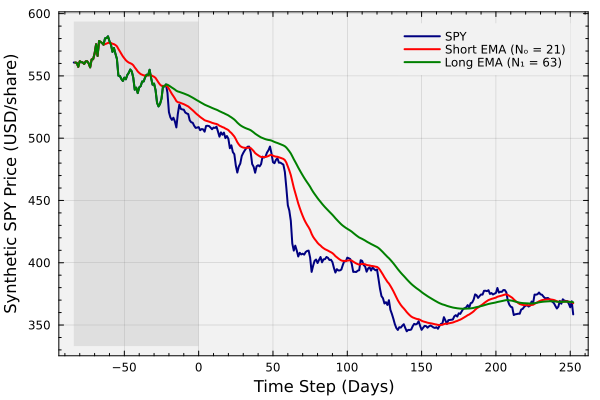

In [16]:
let
    
    # initialize -
    EMA_short = EMA_data.short_term_EMA;
    EMA_long = EMA_data.long_term_EMA;
    offset = Nₒ + N₁; # offset to account for moving average buffer
    
    xvals = S[:,1] .- offset; # shifted time axis
    y_min, y_max = extrema(vcat(S[:,2], EMA_short[:,2], EMA_long[:,2]));
    y_pad = max(0.05 * (y_max - y_min), 1.0e-6);
    y_low = y_min - y_pad;
    y_high = y_max + y_pad;

    # plot with single shaded pre-history block (time < 0) -
    plt = plot(xlabel = "Time Step (Days)", ylabel = "Synthetic SPY Price (USD/share)");
    x_left = minimum(xvals);
    x_right = 0.0;
    plot!(plt, Shape([x_left, x_right, x_right, x_left], [y_low, y_low, y_high, y_high]);
          color = :darkgray, alpha = 0.25, linealpha = 0, label = false);

    plot!(plt, xvals, S[:,2], lw=2, label="SPY", c=:navy);
    plot!(plt, EMA_short[:,1] .- offset, EMA_short[:,2], label = "Short EMA (Nₒ = $Nₒ)", color = :red, xminorticks = true, yminorticks = true, lw=2);
    plot!(plt, EMA_long[:,1] .- offset, EMA_long[:,2], label = "Long EMA (N₁ = $N₁)", color = :green, lw=2);
    plot!(plt, bg="gray95", background_color_outside="white", framestyle = :box, fg_legend = :transparent);

end


Now that we have the moving averages, let's generate a sentiment signal based upon their difference. 

> __Idea:__
> 
> If the short-term moving average is larger than the long-term moving average, we interpret this as a bullish signal. Conversely, if the short-term moving average is less than the long-term moving average, we interpret this as a bearish signal. If the two averages are equal, we interpret this as a neutral signal. So, let's propose a model of our risk-aversion parameter $\lambda$ based on these signals:
> $$
\begin{align*}
\lambda_{t} &= -G\Bigl(\frac{\bar{S}^{(s)}_{t}}{\bar{S}^{(l)}_{t}} - 1\Bigr)\quad{G\in\mathbb{R}_{>0}}\\
\end{align*}
$$
> where $G$ is a scaling (gain) constant, $\bar{S}^{(s)}_{t}$ is the short-term moving average at time $t$, and $\bar{S}^{(l)}_{t}$ is the long-term moving average at time $t$. Because we scale the growth expression in our ticker-preference model by $1/\beta^{\lambda}$, a positive value of $\lambda_{t}$ (bearish signal) will reduce our preference for risky assets, while a negative value of $\lambda_{t}$ (bullish signal) will increase our preference for risky assets.

Let's compute the time series of risk-aversion parameters based on the moving averages. We'll store the results in the `lambda_series::Vector{Float64}` variable:

In [17]:
lambda_series = let

    # initialize: allocate array for lambda time series -
    length_of_S = size(S,1); # total number of time steps
    lambda_series = Array{Float64,2}(undef, length_of_S, 2); # col 1: time, col 2: lambda (dimensionless)
    EMA_short = EMA_data.short_term_EMA;
    EMA_long = EMA_data.long_term_EMA;

    # compute: risk-aversion parameter from EMA crossover -
    for t ∈ 1:length_of_S
        
        lambda_series[t,1] = t; # store time index
        if t <= offset
            lambda_series[t, 2] = 0.0; # neutral during warmup period
        else
            # λ(t) = -G * (EMA_short - EMA_long) / EMA_long
            # positive λ: bearish (short < long), negative λ: bullish (short > long)
            λ_t = -GAIN*(EMA_short[t,2] - EMA_long[t,2]) / EMA_long[t,2];
            lambda_series[t, 2] = λ_t;
        end
    end
    

    lambda_series; # return
end;

__Visualize:__ Plot the risk-aversion parameter $\lambda(t)$ over time. Positive values indicate bearish sentiment (short-term average below long-term), while negative values indicate bullish sentiment (short-term above long-term).

> __What should we expect to see?__ The $\lambda(t)$ trajectory oscillates around zero, reflecting changes in market sentiment. The gain parameter $G$ controls the scale of these signals. During the buffer period (gray region), we set $\lambda(t) = 0$ because the moving averages are not yet formed.

Does the sign of $\lambda(t)$ match the crossover behavior in the previous plot?

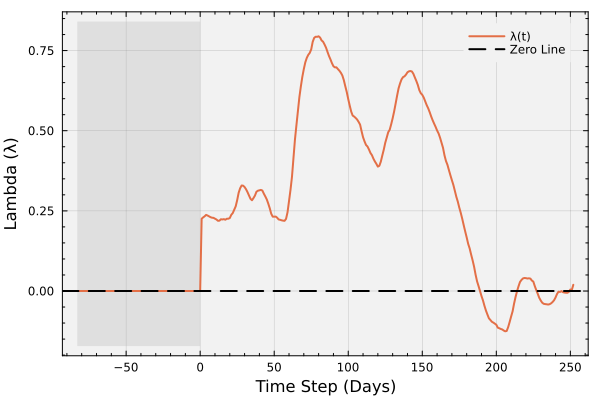

In [18]:
let
    # plot -
    MA_short = EMA_data.short_term_EMA;
    EMA_long = EMA_data.long_term_EMA;
    offset = Nₒ + N₁; # offset to account for moving average buffer

    xvals = lambda_series[:,1] .- offset; # shifted time axis
    y_min, y_max = extrema(lambda_series[:,2]);
    y_pad = max(0.05 * (y_max - y_min), 1.0e-6);
    y_low = y_min - y_pad;
    y_high = y_max + y_pad;
    x_left = minimum(xvals);
    x_right = 0.0;

    plt = plot(xlabel = "Time Step (Days)", ylabel = "Lambda (λ)", bg="gray95", 
        background_color_outside="white", framestyle = :box, fg_legend = :transparent, legend=:topright, 
        xminorticks = true, yminorticks = true);
    plot!(plt, Shape([x_left, x_right, x_right, x_left], [y_low, y_low, y_high, y_high]);
          color = :darkgray, alpha = 0.25, linealpha = 0, label = false);
    
    plot!(plt, lambda_series[:,1] .- offset, lambda_series[:,2], xlabel = "Time Step (Days)", lw=2, label="λ(t)");
    hline!([0.0], linestyle = :dash, color = :black, label = "Zero Line", lw=2);
end

Next, we generate synthetic price trajectories for each ticker in our portfolio using the single index model. The market growth rate $g_{m}$ from the SPY simulation drives the asset returns through the single index model parameters $\alpha$ and $\beta$ that we estimated from historical data. We store the synthetic prices in the `future_share_price_array::Array{Float64,2}` array (the first column is time, and subsequent columns correspond to each ticker in `my_list_of_tickers`):

In [19]:
future_share_price_array = let

    # initialize: allocate array for synthetic price trajectories -
    number_of_time_steps = size(S,1);
    future_share_price_array = Array{Float64,2}(undef, number_of_time_steps, K+1); # col 1: time, cols 2-(K+1): prices
    
    # simulate: generate price trajectory for each ticker using SIM -
    for ticker ∈ eachindex(my_list_of_tickers)
    
        # extract: single index model parameters for this ticker -
        ticker_symbol = my_list_of_tickers[ticker];
        sim_params = sim_model_parameters[ticker_symbol];
        αᵢ = sim_params.alpha; # SIM intercept (units: 1/year)
        βᵢ = sim_params.beta; # SIM beta, market sensitivity (dimensionless)
        TV = sim_params.training_variance; # idiosyncratic variance (units: 1/year²)
        σᵢ = sqrt(Δt*TV); # per-period standard deviation (dimensionless)
        Sᵢ = initial_share_price_dict[ticker_symbol]; # initial price (units: USD/share)

        # setup: initial conditions -
        future_share_price_array[1,1] = 1; # time index
        future_share_price_array[1,ticker+1] = Sᵢ; # initial price (USD/share)
        
        # simulate: SIM equation gᵢ = αᵢ + βᵢ*gₘ + εᵢ -
        for t ∈ 2:number_of_time_steps
            gᵢ = αᵢ + βᵢ*(gₘ[t-1]) + (σᵢ*sqrt(Δt))*randn(); # asset growth rate (1/year)
            future_share_price_array[t,1] = t; # time index
            future_share_price_array[t,ticker+1] = future_share_price_array[t-1,ticker+1]*exp(gᵢ*Δt); # price update
        end    
    end

    future_share_price_array; # return
end

336×5 Matrix{Float64}:
   1.0  230.19   415.6    590.0    164.12
   2.0  229.94   415.841  590.007  164.093
   3.0  228.745  413.156  586.509  163.688
   4.0  231.224  417.06   590.772  164.347
   5.0  231.135  416.885  590.482  164.318
   6.0  230.974  416.903  590.796  164.154
   7.0  230.457  415.929  589.556  163.904
   8.0  231.419  417.658  591.449  164.36
   9.0  231.444  418.231  591.435  164.413
  10.0  230.893  416.852  590.483  164.043
   ⋮                               
 328.0  160.103  292.561  463.933  128.601
 329.0  162.276  296.087  468.491  129.221
 330.0  161.932  294.834  467.152  129.06
 331.0  161.89   294.959  467.288  129.11
 332.0  161.843  294.912  467.615  129.008
 333.0  161.103  292.793  465.49   128.701
 334.0  159.571  290.441  461.787  128.135
 335.0  162.177  295.115  467.828  128.976
 336.0  156.747  285.723  456.44   127.013

__Visualize:__ Plot the synthetic share price trajectory for a selected ticker. The trade bot does not have access to future prices; it only sees the price history up to the current time.

> __What should we expect to see?__ The gray region indicates the buffer period used to initialize the moving averages. Because we use synthetic data, the price trajectory changes each time we run the simulation. The HMM model generates return distributions that reflect market regimes learned from historical data.

Change `ticker_to_plot` to view other assets in the portfolio.

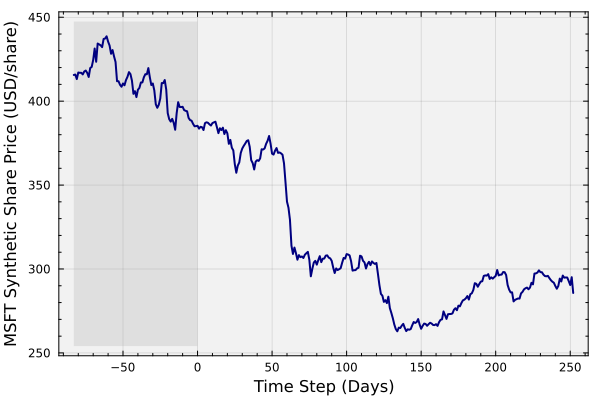

In [20]:
let

    # initialize -
    ticker_to_plot = "MSFT";
    ticker_index = findfirst(isequal(ticker_to_plot), my_list_of_tickers);
    T = future_share_price_array[:,1] .- offset;

    xvals = T; # shifted time axis
    y_min, y_max = extrema(future_share_price_array[:,ticker_index+1]);
    y_pad = max(0.05 * (y_max - y_min), 1.0e-6);
    y_low = y_min - y_pad;
    y_high = y_max + y_pad;
    x_left = minimum(xvals);
    x_right = 0.0;

    plt = plot(xlabel = "Time Step (Days)", ylabel = "Synthetic Share Price (USD/share)", bg="gray95", 
        background_color_outside="white", framestyle = :box, fg_legend = :transparent, 
        xminorticks = true, yminorticks = true);

    plot!(plt, Shape([x_left, x_right, x_right, x_left], [y_low, y_low, y_high, y_high]);
          color = :darkgray, alpha = 0.25, linealpha = 0, label = false);

    plot!(plt, T, future_share_price_array[:,ticker_index+1], xlabel = "Time Step (Days)", 
        ylabel = "$(ticker_to_plot) Synthetic Share Price (USD/share)", legend = false, lw=2, label="$(ticker_to_plot)", c=:navy);

    plot!(plt, bg="gray95", background_color_outside="white");
end

___

## Task 3: Implement the Trade Bot Loop
In this task, we implement the trade bot simulation. The bot uses the risk-aversion parameter $\lambda(t)$ from the moving average crossover to inform portfolio reallocation decisions. We compare the trade bot performance against two benchmark investments: a passive SPY ETF position and a risk-free STRIPS bond.  Let's start by generating the wealth trajectories for the alternative investments.

### Wealth Calculation for a Risk-Free Alternative Investment
First, consider the risk-free STRIPS bond investment. In this case, the initial investment amount will grow at the risk-free rate until maturity. Let's compute the wealth time series for this investment and store it in the `wealth_alternative_investment_STRIPS::Array{Float64,1}` variable:

In [21]:
wealth_alternative_investment_STRIPS = let

    # initialize: allocate wealth array for STRIPS investment -
    maximum_number_trading_days = number_of_simulation_days;
    wealth_array = Array{Float64, 1}(undef, maximum_number_trading_days); # wealth trajectory (USD)
    wealth_array[1] = B; # initial investment equals budget (USD)

    # compute: continuous compounding at risk-free rate W(t) = B*exp(r*t) -
    for day_index in 2:maximum_number_trading_days
        t = (day_index - 1) * Δt; # elapsed time (years)
        wealth_generated = B * exp(risk_free_rate * t); # risk-free wealth (USD)
        wealth_array[day_index] = wealth_generated;
    end
   
    wealth_array; # return
end;

### Alternative Investment: SPY ETF
Next, consider an alternative investment in the SPY ETF. In this case, the initial investment amount will grow according to the price changes of the SPY ETF. Let's compute the wealth time series for this investment and store it in the `wealth_alternative_investment_SPY::Array{Float64,1}` variable:

In [22]:
wealth_alternative_investment_SPY = let

    # initialize: allocate wealth array for SPY buy-and-hold -
    wealth_array = Array{Float64, 1}(undef, number_of_simulation_days); # wealth trajectory (USD)
    initial_SPY_price = S[offset, 2]; # SPY price at simulation start (USD/share)
    initial_SPY_shares = B / initial_SPY_price; # number of shares purchased (shares)
    tradingdayindexvector = range(offset + 1, stop = offset + number_of_simulation_days, step = 1) |> collect;

    # compute: wealth = shares * current price for each day -
    for day_index ∈ eachindex(tradingdayindexvector)
        i = tradingdayindexvector[day_index];
        current_SPY_price = S[i, 2]; # SPY price at this time step (USD/share)
        wealth_array[day_index] = initial_SPY_shares * current_SPY_price; # portfolio value (USD)
    end

    wealth_array; # return
end;

### What Information Should We Use to Update the Preference Model?
Now that we have the alternative investment wealth trajectories, let's implement the trade bot loop. At each (reallocation) time step, the trade bot will update its preference model based on new information and reallocate its portfolio accordingly.

Given that our preference models are risk-aware single index models augmented with ticker-picker preferences, we could do several things here. However, let's update the preference coefficients $\gamma_{i}$ using a new value for the expected market growth rate, which we assume is an exponential moving average (EMA) of the market excess growth rate.

We store the SPY growth rate moving average in the `exponential_moving_average_market_growth::Array{Float64,1}` variable:

In [23]:
exponential_moving_average_market_growth = let

    # initialize: EMA smoothing factor and output array -
    α = 2.0 / (N₂ + 1.0); # smoothing factor (dimensionless)
    ema_array = Array{Float64,1}(undef, length(gₘ)); # smoothed growth rate (1/year)
    ema_array[1] = gₘ[1]; # initialize with first observation

    # compute: EMA of market growth rate -
    for t in 2:length(gₘ)
        ema_array[t] = α * gₘ[t] + (1 - α) * ema_array[t-1]; # EMA update
    end

    ema_array; # return
end;

__Visualize:__ Plot the market growth rate alongside the exponential moving average. The EMA (orange) removes noise from market returns (blue), revealing the underlying trend.

> __Why use an EMA of SPY return?__ The EMA smooths out short-term fluctuations, allowing the trade bot to focus on longer-term trends. The $N_{2}$ parameter controls how quickly the EMA responds to changes.

Does the EMA lag behind large return spikes? How does this affect trading decisions?

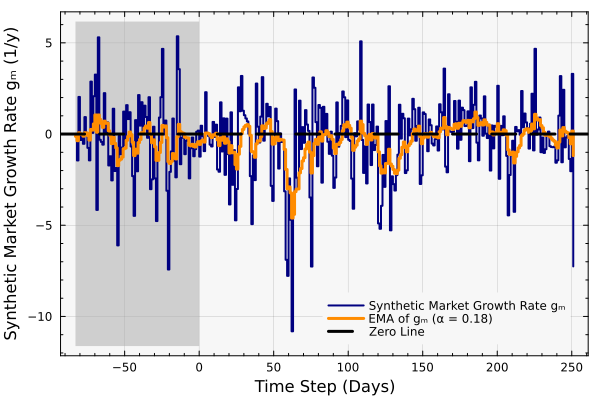

In [24]:
let

    # initialize -
    α = 2.0 / (N₂ + 1.0) |> x-> round(x, digits=2); # smoothing factor
    number_of_time_steps = length(gₘ);
    T = 1:number_of_time_steps;

    xvals = T .- offset; # shifted time axis
    y_min, y_max = extrema(gₘ);
    y_pad = max(0.05 * (y_max - y_min), 1.0e-6);
    y_low = y_min - y_pad;
    y_high = y_max + y_pad;
    x_left = minimum(xvals);
    x_right = 0.0;

    plt = plot(xlabel = "Time Step (Days)", ylabel = "Synthetic Market Growth Rate gₘ (1/y)", bg="gray95", 
        background_color_outside="white", framestyle = :box, fg_legend = :transparent);

    plot!(plt, Shape([x_left, x_right, x_right, x_left], [y_low, y_low, y_high, y_high]);
          color = :darkgray, alpha = 0.5, linealpha = 0, label = false);


    plot!(plt, T .- offset, gₘ, label="Synthetic Market Growth Rate gₘ", lw=2, linecolor=:navy, linetype=:steppost, 
        xminorticks = true, yminorticks = true);
    plot!(plt, T .- offset, exponential_moving_average_market_growth, label="EMA of gₘ (α = $α)", lw=3, linecolor=:darkorange, linetype=:steppost)
    plot!(plt, bg="gray97", background_color_outside="white", framestyle = :box, fg_legend = :transparent)
    hline!([0.0], linestyle = :dash, color = :black, label = "Zero Line", lw=3);
end

Next, we construct the context model for the trade bot. The context model encapsulates the budget, ticker list, market data, market factor estimates, single index model parameters, and the risk-aversion parameter. We store the context model in the `contextmodel::MySimpleRobotInvestorContextModel` variable:

In [25]:
contextmodel = build(MySimpleRobotInvestorContextModel, (
    B = B, # budget (USD)
    tickers = my_list_of_tickers, # what is my universe of tickers
    marketdata = future_share_price_array, # future share price data (USD/share)
    marketfactor = exponential_moving_average_market_growth, # market factor (EMA of market growth)
    singleindexmodel_parameters = sim_model_parameters, # parameters for the single index model (estimated from 2014 - 2024 historical data)
    λ = λ, # initial risk-aversion parameter
    Δt = Δt, # time step size
    ϵ = 0.1, # minimum number of shares to hold (shares)
));

When should we rebalance our portfolio?

> __Rebalancing Implementation:__ At each trading day $i$, if $a_{i} = 1$, we liquidate the current portfolio at the open. We assume that we get the open price for each asset on that day. We then recompute the optimal number of shares (where we now update the $\gamma_{i}$ coefficients based on the latest market information) and purchase those shares at a random price during that trading day (between the open and close). If $a_{i} = 0$, we hold the current portfolio allocation.

Let's set a value for the reallocation vector $\mathbf{a}$:

In [26]:
a = let

    # option 1: reallocate every day (a[i] = 1 triggers reallocation) -
    a = ones(Int,number_of_simulation_days);
    
    # option 2: never reallocate (buy-and-hold) -
    # a = zeros(number_of_simulation_days);

    a; # return
end;

Now we execute the trade bot simulation. 

> __What is happening?__ For each trading day, if the reallocation signal $a_{i} = 1$, we liquidate the current portfolio at the open price, update the risk-aversion parameter based on the previous day's moving average crossover, and compute a new optimal allocation. If $a_{i} = 0$, we hold the current portfolio. See the pseudo-code in the lecture notes for additional details.

We store the results in the `tradebot_results_dictionary::Dict{Int64, NamedTuple}` dictionary:

In [27]:
tradebot_results_dictionary = let

    # initialize: results dictionary and trading day indices -
    tradebot_results_dictionary = Dict{Int64, NamedTuple}();
    tradingdayindexvector = range(offset + 1, stop = offset + number_of_simulation_days, step = 1) |> collect;

    # setup: compute initial portfolio allocation at t=0 -
    tradebot_results_dictionary[0] = shares(offset-1, contextmodel);

    # simulate: process each trading day -
    for day_index ∈ eachindex(tradingdayindexvector)
        actual_trading_day_index = tradingdayindexvector[day_index];
        action = a[day_index]; # reallocation signal: 1 = reallocate, 0 = hold
        
        if (action == 1)
            
            # REALLOCATION DAY: liquidate and rebalance portfolio -
            mycontextmodel = deepcopy(contextmodel); # copy context for modification
            λᵢ = lambda_series[actual_trading_day_index-1, 2]; # previous day's lambda
            cash = tradebot_results_dictionary[day_index - 1].cash; # available cash (USD)
            nₒ = tradebot_results_dictionary[day_index - 1].shares; # current share holdings
            
            # compute: liquidation value of current holdings -
            liquidation_value = 0.0;
            for i ∈ eachindex(nₒ)
                price_at_day = future_share_price_array[actual_trading_day_index, i + 1]; # open(?) price (USD/share)
                liquidation_value += nₒ[i] * price_at_day; # position value (USD)
            end

            # update: context with new budget and risk-aversion -
            mycontextmodel.B = cash + liquidation_value; # total available capital (USD)
            mycontextmodel.λ = λᵢ; # updated risk-aversion from EMA crossover
            
            # compute: new optimal portfolio allocation -
            new_results = shares(actual_trading_day_index, mycontextmodel);
            tradebot_results_dictionary[day_index] = new_results;
        else

            # HOLD DAY: carry forward previous portfolio -
            tradebot_results_dictionary[day_index] = tradebot_results_dictionary[day_index-1];
        end
    end

    tradebot_results_dictionary # return
end;

### Wealth Calculation for the Tradebot
Let's compute the wealth generated by the dynamic reallocation strategy. For each trading day, track positions and values based on the reallocation results. On days without reallocation, carry forward the previous portfolio; on reallocation days, use the new portfolio weights computed from updated market information and preferences.

We store the wealth in the `wealth_array_tradebot::Array{Float64,2}` where each row is a day. The columns are given by:
* Columns $i=1\;\text{to}\;K$: These columns hold the value associated with our position in ticker $i$. If we don't hold ticker $i$, then this entry will be `0`. 
* Column $K+1$: This column holds the total value of all shares in the portfolio (valued at the close price for the day).
* Column $K+2$: This column holds the cash on hand (cash from share sales or unallocated capital).
* Column $K+3$: The total value of the portfolio (liquidation value plus cash on hand).

Construct the wealth array for this case:

In [28]:
wealth_array_tradebot = let

    # initialize: setup array dimensions -
    my_portfolio_tickers = contextmodel.tickers;
    number_of_tickers_in_portfolio = length(my_portfolio_tickers);
    tradingdayindexvector = range(offset + 1, stop = offset + number_of_simulation_days, step = 1) |> collect;
    # columns: [ticker_1...ticker_K, total_shares_value, cash, total_wealth]
    wealth_array = Array{Float64,2}(undef, length(tradingdayindexvector), number_of_tickers_in_portfolio+3);
    fill!(wealth_array, 0.0); 
    
    # setup: compute initial wealth at day 1 -
    for ticker ∈ eachindex(my_portfolio_tickers)
        n_shares = tradebot_results_dictionary[0].shares[ticker]; # shares held
        price_at_purchase = tradebot_results_dictionary[0].price[ticker]; # purchase price (USD/share)
        wealth_array[1, ticker] = n_shares * price_at_purchase; # position value (USD)
    end
    wealth_array[1, end-2] = sum(wealth_array[1, 1:end-3]); # total shares value (USD)
    wealth_array[1, end-1] = tradebot_results_dictionary[0].cash; # cash on hand (USD)
    wealth_array[1, end] = sum(wealth_array[1, (end-2):(end-1)]); # total portfolio value (USD)

    # compute: wealth for each subsequent trading day -
    for day_index ∈ eachindex(tradingdayindexvector)
        actual_day_index = tradingdayindexvector[day_index];
        results_of_day = tradebot_results_dictionary[day_index];
        
        # compute: value of each position at current prices -
        for ticker ∈ eachindex(my_portfolio_tickers)
            n_shares = results_of_day.shares[ticker]; # shares held
            price_at_day = future_share_price_array[actual_day_index, ticker+1]; # current price (USD/share)
            wealth_array[day_index, ticker] = n_shares * price_at_day; # position value (USD)
        end
        
        # compute: portfolio totals -
        wealth_array[day_index, end-2] = sum(wealth_array[day_index, 1:end-3]); # total shares value (USD)
        wealth_array[day_index, end-1] = results_of_day.cash; # cash on hand (USD)
        wealth_array[day_index, end] = sum(wealth_array[day_index, (end-2):(end-1)]); # total portfolio value (USD)end;
    end
    
    wealth_array; # return
end;

__Visualize:__ Compare portfolio wealth trajectories across all strategies over the full investment period.

> __What do we expect?__ Daily reallocation __may__ provide more responsiveness to market changes than buy-and-hold, but the magnitude of improvement depends on market regime and reallocation effectiveness. If markets are trending (strongly up or down), buy-and-hold may outperform reallocation due to lower transaction sensitivity. In volatile or mean-reverting markets, reallocation can capture opportunities missed by static positioning.

> __Color Legend:__
> * **Blue:** Tradebot daily reallocation, adjusts positions each reallocation day (controlled using the $\mathbf{a}$ vector)
> * **Red:** S&P 500 ETF (SPY) passive market index. This serves as a benchmark for overall market performance.
> * **Green:** Risk-free STRIPS bond. This is the risk-free benchmark.

Do we see an improvement with reallocation?

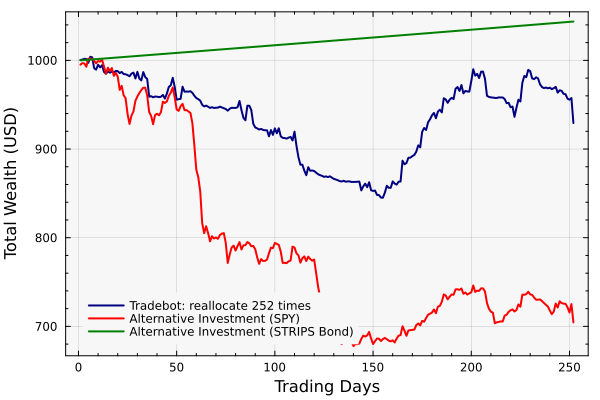

In [29]:
let

    plot(wealth_array_tradebot[:, end],
        xlabel = "Trading Days",
        ylabel = "Total Wealth (USD)",
        label = "Tradebot: reallocate $(length(a[a .== 1])) times",
        lw = 2,
        linecolor = :navy,
        xminorticks = true,
        yminorticks = true,
    );

    plot!(wealth_alternative_investment_SPY,
        label = "Alternative Investment (SPY)",
        linecolor = :red,   
        lw = 2,
    );

    plot!(wealth_alternative_investment_STRIPS,
        label = "Alternative Investment (STRIPS Bond)",
        linecolor = :green,   
        lw = 2,
    );

    plot!(bg="gray97", background_color_outside="white", framestyle = :box, fg_legend = :transparent)
end

Let's examine how the number of shares in each position evolves over time. We extract the share counts from the results dictionary and store them in the `N::Array{Float64,2}` array where rows correspond to tickers and columns correspond to trading days:

In [30]:
N = let
    
    # initialize: setup array dimensions -
    results_case = tradebot_results_dictionary;
    tradingdayindexvector = range(offset + 1, stop = offset + number_of_simulation_days, step = 1) |> collect;
    my_portfolio_tickers = my_list_of_tickers;
    number_of_tickers_in_portfolio = length(my_portfolio_tickers);
    N = Array{Float64,2}(undef, number_of_tickers_in_portfolio, length(tradingdayindexvector)); # rows: tickers, cols: days

    # extract: share counts for each ticker on each day -
    for day ∈ eachindex(tradingdayindexvector)
        result_of_day = results_case[day];
        for ticker ∈ eachindex(my_portfolio_tickers)
            N[ticker, day] = result_of_day.shares[ticker]; # number of shares held
        end
    end

    # normalize: rescale to [0,1] for visualization (optional) -
    N̂ = (N .- minimum(N)) ./ (maximum(N) - minimum(N));
    # Gray.(N̂) # uncomment to display grayscale heatmap
    
    N # return raw share counts
end

4×252 Matrix{Float64}:
 0.1  0.1  0.1  0.1  1.63771   1.62754   …  2.09088   0.1  0.1  2.01763   0.1
 0.1  0.1  0.1  0.1  0.859261  0.872456     1.11742   0.1  0.1  1.05484   0.1
 0.1  0.1  0.1  0.1  0.505013  0.508464     0.55604   0.1  0.1  0.510123  0.1
 0.1  0.1  0.1  0.1  0.211014  0.219937     0.262096  0.1  0.1  0.622645  0.1

### How do our preferences evolve for the reallocation case?
We visualize the preference coefficients across trading days for the daily reallocation strategy. 

> __What do we expect to see?__ The preferences in the reallocation case should vary over time as the portfolio adjusts to new information. The portfolio preferences are sensitive to market changes, particularly during volatile periods. In these cases, we should see large shifts in preference allocations, sometimes moving toward cash-only positions. Light pixels indicate high preference (more shares held), while dark pixels indicate low preference (fewer shares held).

Do the preferences change with market conditions?

In [33]:
let

    # initialize: setup array dimensions -
    results_case = tradebot_results_dictionary;
    tradingdayindexvector = range(offset + 1, stop = offset + number_of_simulation_days, step = 1) |> collect;
    my_portfolio_tickers = my_list_of_tickers;
    number_of_tickers_in_portfolio = length(my_portfolio_tickers);
    Γ = Array{Float64,2}(undef, number_of_tickers_in_portfolio, length(tradingdayindexvector)); # rows: tickers, cols: days

    # extract: preference coefficients for each ticker on each day -
    for day ∈ eachindex(tradingdayindexvector)
        result_of_day = results_case[day];
        for ticker ∈ eachindex(my_portfolio_tickers)
            Γ[ticker, day] = result_of_day.gamma[ticker]; # preference coefficient (dimensionless)
        end
    end

    # normalize: rescale to [0,1] for visualization -
    Γ̂ = (Γ .- minimum(Γ)) ./ (maximum(Γ) - minimum(Γ));
    # Gray.(Γ) # unscaled: display grayscale heatmap of preferences
    Gray.(Γ̂) # normalized: display grayscale heatmap of preferences
end

## Summary
This example demonstrates how to build and test a trade bot that combines hidden Markov models for price simulation, moving average crossover signals for timing, and risk-aware utility maximization for portfolio allocation.

> __Key Takeaways:__
> 
> * __Synthetic data generation:__ Hidden Markov models and single index model parameters from historical data generate realistic price trajectories for backtesting portfolio strategies.
> * __Moving average crossover signals:__ The ratio of short-term to long-term exponential moving averages provides a risk-aversion parameter that adapts portfolio allocations to changing market conditions.
> * __Benchmark comparison:__ Evaluating trade bot performance against passive alternatives (SPY, risk-free bonds) reveals whether dynamic reallocation adds value relative to transaction costs and model uncertainty.


The framework extends to other signal generation methods and reallocation strategies.
___

## Disclaimer and Risks
__This content is offered solely for training and informational purposes__. No offer or solicitation to buy or sell securities or derivative products or any investment or trading advice or strategy is made, given, or endorsed by the teaching team. 

__Trading involves risk__. Carefully review your financial situation before investing in securities, futures contracts, options, or commodity interests. Past performance, whether actual or indicated by historical tests of strategies, is no guarantee of future performance or success. Trading is generally inappropriate for someone with limited resources, investment or trading experience, or a low-risk tolerance. Only risk capital that is not required for living expenses should be used.

__You are fully responsible for any investment or trading decisions you make__. Such decisions should be based solely on evaluating your financial circumstances, investment or trading objectives, risk tolerance, and liquidity needs.

___